# Generalizability Study

In [97]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
experiment = "generalizability_study"

In [99]:
dataset = "aitv2"
scenario = "santos_fox"
test_scenario = "fox"

# dataset = "darpa2000"
# scenario = "s1_inside_s1_dmz"
# test_scenario = "s1_dmz"

In [100]:
def compute_weighted_f1(metrics):
    total_support = 0
    weighted_f1_sum = 0

    for class_name, stats in metrics['per_class'].items():
        support = stats['TP'] + stats['FN']
        total_support += support
        weighted_f1_sum += stats['f1'] * support

    weighted_f1 = weighted_f1_sum / total_support

    return weighted_f1


In [101]:
experiments = {}

In [102]:
metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())

f1_scores = {}
false_positives = {}
detection_rates = {}

for file_path in file_paths:
    data = np.load(file_path, allow_pickle=True)
    metrics = data["metrics"].item()

    experiment_name = str(file_path.stem)
    if "baseline" in experiment_name:
        exp_name = f"logic_{scenario}"
    else:
        train_setting = experiment_name.split("_")[3]
        exp_name = f"dpl_{train_setting}_{scenario}"
    print(f"Experiment: {exp_name}")
    
    weighted_f1 = compute_weighted_f1(metrics)
    
    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }
    print(weighted_f1)
    print(metrics["per_class"]["benign"])


Experiment: dpl_pretrained_santos_fox
0.9211403791589098
{'TP': 399614, 'FP': 31511, 'FN': 401, 'precision': 0.9269098289359234, 'recall': 0.9989975375923403, 'f1': 0.9616045431575908}
Experiment: dpl_endtoend_santos_fox
0.944663995791776
{'TP': 398944, 'FP': 22889, 'FN': 1071, 'precision': 0.9457391906275706, 'recall': 0.9973226004024849, 'f1': 0.9708461905364496}
Experiment: logic_santos_fox
0.9533174914609737
{'TP': 400000, 'FP': 14748, 'FN': 15, 'precision': 0.964441058184729, 'recall': 0.9999625014061972, 'f1': 0.981880620499458}


In [103]:
metrics_dir = Path(f"../../experiments/{dataset}/{test_scenario}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())

In [104]:
f1_scores = {}
false_positives = {}
detection_rates = {}

for file_path in file_paths:

    data = np.load(file_path, allow_pickle=True)
    metrics = data["metrics"].item()

    experiment_name = str(file_path.stem)
    if "baseline" in experiment_name:
        exp_name = f"logic_{test_scenario}"
    else:
        train_setting = experiment_name.split("_")[3]
        exp_name = f"dpl_{train_setting}_{test_scenario}"
    print(f"Experiment: {exp_name}")

    weighted_f1 = compute_weighted_f1(metrics)

    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }


Experiment: dpl_pretrained_fox
Experiment: dpl_endtoend_fox


In [105]:
metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = str(file_path.stem)
    model_name = experiment_name.split("_")[0]
    exp_name = f"lstm_{model_name}_{scenario}"
    print(f"Experiment: {exp_name}")

    weighted_f1 = compute_weighted_f1(metrics)

    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }


Experiment: lstm_multiclass_santos_fox


In [106]:
metrics_dir = Path(f"../../experiments/{dataset}/{test_scenario}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = str(file_path.stem)
    model_name = experiment_name.split("_")[0]
    exp_name = f"lstm_{model_name}_{test_scenario}"
    print(f"Experiment: {exp_name}")

    weighted_f1 = compute_weighted_f1(metrics)

    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }

    print(weighted_f1)
    print(metrics["per_class"]["benign"])


Experiment: lstm_multiclass_fox
0.9942337727061006
{'TP': 119535, 'FP': 342, 'FN': 470, 'precision': 0.9971470757526465, 'recall': 0.9960834965209783, 'f1': 0.9966150023761683}


In [107]:
experiments

{'dpl_pretrained_santos_fox': {'f1_score': 0.6387822811135055,
  'weighted_f1': 0.9211403791589098,
  'false_alarm_rate': 0.0010024624076597128,
  'detection_rate': 0.5574919252913917},
 'dpl_endtoend_santos_fox': {'f1_score': 0.7205256221112508,
  'weighted_f1': 0.944663995791776,
  'false_alarm_rate': 0.002677399597515093,
  'detection_rate': 0.6785704255020363},
 'logic_santos_fox': {'f1_score': 0.561060744936178,
  'weighted_f1': 0.9533174914609737,
  'false_alarm_rate': 3.74985938027324e-05,
  'detection_rate': 0.7928942564246595},
 'dpl_pretrained_fox': {'f1_score': 0.8710947670962474,
  'weighted_f1': 0.9984565331171017,
  'false_alarm_rate': 0.0005083121536602641,
  'detection_rate': 0.9927912746337125},
 'dpl_endtoend_fox': {'f1_score': 0.8889254304499252,
  'weighted_f1': 0.9984710189897824,
  'false_alarm_rate': 0.000991625348943794,
  'detection_rate': 0.9955062491223143},
 'lstm_multiclass_santos_fox': {'f1_score': 0.5960548559435506,
  'weighted_f1': 0.898050929950371,
  

In [108]:
plots_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")
plots_dir.mkdir(parents=True, exist_ok=True)

In [109]:
def metrics_heatmap(
    experiments,
    selected_models=None,
    global_bounds=None,
    plots_title="",
    plots_dir=None,
    plots_name=""
):

    metrics = ["f1_score", "weighted_f1", "detection_rate", "false_alarm_rate"]

    metric_labels = ["Macro F1", "Weighted F1", "Detection Rate", "False Alarm Rate"]

    colormaps = {
        "f1_score": sns.color_palette("RdYlGn", as_cmap=True),
        "weighted_f1": sns.color_palette("RdYlGn", as_cmap=True),
        "detection_rate": sns.color_palette("RdYlGn", as_cmap=True),
        "false_alarm_rate": sns.color_palette("RdYlGn", as_cmap=True),
    }

    if selected_models is None:
        selected_models = list(experiments.keys())

    model_labels = [
        m.replace("dpl_", "")
         .replace("lstm_multiclass_", "")
         .replace("endtoend_", "")
         .replace("pretrained_", "")
         .replace("logic_", "")

         .replace("santos_fox", "SANTOS -> FOX \n")
         .replace("fox", "FOX -> FOX \n")
         .replace("s1_inside_s1_dmz", "INSIDE -> DMZ \n")
         .replace("s1_dmz", "DMZ -> DMZ \n")

        for m in selected_models
    ]

    data = np.array([
        [experiments[m][metric] for metric in metrics]
        for m in selected_models
    ])

    data_norm = np.zeros_like(data, dtype=float)
    for j, metric in enumerate(metrics):
        vmin, vmax = global_bounds[metric]
        col = data[:, j]
        col = np.clip(col, vmin, vmax)
        data_norm[:, j] = col - vmin

    # Plot
    sns.set_theme(style="white")
    
    fig_height = max(1.8, len(selected_models) * 0.65)
    fig, ax = plt.subplots(figsize=(7.5, fig_height))

    sns.heatmap(
        data_norm,
        cmap="Greys",   # placeholder; we override per-cell coloring below
        cbar=False,
        linewidths=1.5,
        linecolor="white",
        ax=ax
    )

    for i in range(data.shape[0]):
        for j, metric in enumerate(metrics):

            vmin, vmax = global_bounds[metric]
            val = data[i, j]

            if metric == "false_alarm_rate":
                norm_val = (vmax - np.clip(val, vmin, vmax)) / (vmax - vmin)
            else:
                norm_val = (np.clip(val, vmin, vmax) - vmin) / (vmax - vmin)

            color = colormaps[metric](norm_val)

            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor="white",
                linewidth=1.5
            ))

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black" if norm_val < 0.6 else "white"
            )

    # Labels
    ax.set_xticklabels(metric_labels, rotation=0, fontsize=11)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    ax.set_yticklabels(model_labels, rotation=0, fontsize=10)

    ax.set_title(plots_title, fontsize=12, pad=18)

    plt.tight_layout()

    if plots_dir:
        plots_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(plots_dir / f"metrics_heatmap_{plots_name}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [110]:
for exp_name in experiments.keys():
    print(exp_name)

dpl_pretrained_santos_fox
dpl_endtoend_santos_fox
logic_santos_fox
dpl_pretrained_fox
dpl_endtoend_fox
lstm_multiclass_santos_fox
lstm_multiclass_fox


In [111]:
def compute_global_bounds(experiments, metrics):
    bounds = {}

    for metric in metrics:
        values = [
            experiments[m][metric]
            for m in experiments
        ]

        if metric == "false_alarm_rate":
            bounds[metric] = (0.0, max(values))  # often better to anchor at 0
        else:
            bounds[metric] = (min(values), max(values))

    return bounds

In [112]:
bounds = compute_global_bounds(experiments, metrics=["f1_score", "weighted_f1", "detection_rate", "false_alarm_rate"])

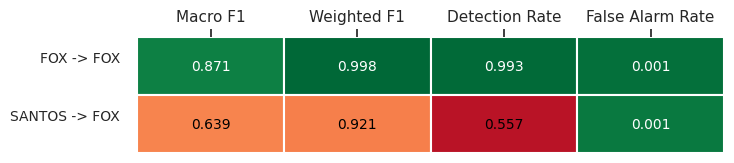

In [113]:
# Pretrained models only

top_models = [
    f"dpl_pretrained_{test_scenario}",
    f"dpl_pretrained_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    global_bounds=bounds,
    # plots_title="DeepProbLog Pretrained",
    plots_dir=plots_dir,
    plots_name="dpl_pretrained"
)

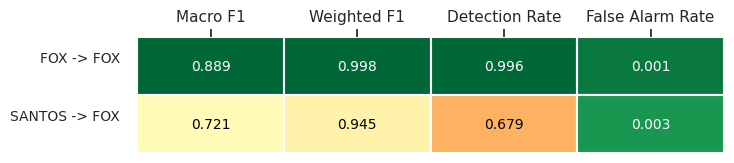

In [114]:
# Scratch models only

top_models = [
    f"dpl_endtoend_{test_scenario}",
    f"dpl_endtoend_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="DeepProbLog End-to-End",
    global_bounds=bounds,
    plots_dir=plots_dir,
    plots_name="dpl_endtoend"
)

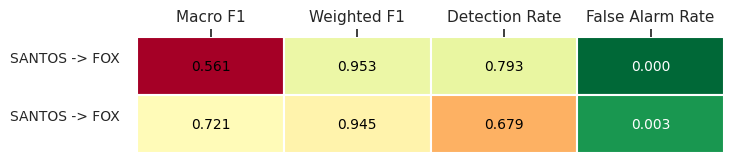

In [115]:
# Logic baseline

top_models = [
    f"logic_{scenario}",
    f"dpl_endtoend_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="Logic Baseline",
    global_bounds=bounds,
    plots_dir=plots_dir,
    plots_name="logic_baseline"
)

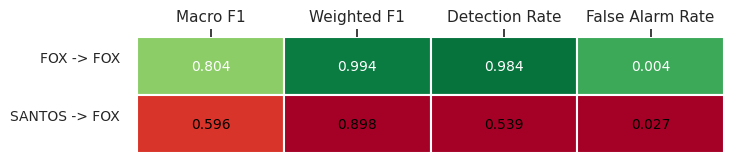

In [116]:
# Neural baseline

top_models = [
    f"lstm_multiclass_{test_scenario}",
    f"lstm_multiclass_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="Neural Baseline",
    global_bounds=bounds, 
    plots_dir=plots_dir,
    plots_name="neural_baseline"
)

## Metrics

In [117]:
experiments_df = pd.DataFrame(experiments).T
experiments_df

,f1_score,weighted_f1,false_alarm_rate,detection_rate
dpl_pretrained_santos_fox,0.638782,0.921140,0.001002,0.557492
dpl_endtoend_santos_fox,0.720526,0.944664,0.002677,0.678570
logic_santos_fox,0.561061,0.953317,0.000037,0.792894
dpl_pretrained_fox,0.871095,0.998457,0.000508,0.992791
dpl_endtoend_fox,0.888925,0.998471,0.000992,0.995506
lstm_multiclass_santos_fox,0.596055,0.898051,0.026569,0.538815
lstm_multiclass_fox,0.803507,0.994234,0.003917,0.983991


In [118]:
experiments_sorted = experiments_df.sort_values(by='f1_score', ascending=False)
experiments_sorted

,f1_score,weighted_f1,false_alarm_rate,detection_rate
dpl_endtoend_fox,0.888925,0.998471,0.000992,0.995506
dpl_pretrained_fox,0.871095,0.998457,0.000508,0.992791
lstm_multiclass_fox,0.803507,0.994234,0.003917,0.983991
dpl_endtoend_santos_fox,0.720526,0.944664,0.002677,0.678570
dpl_pretrained_santos_fox,0.638782,0.921140,0.001002,0.557492
lstm_multiclass_santos_fox,0.596055,0.898051,0.026569,0.538815
logic_santos_fox,0.561061,0.953317,0.000037,0.792894


In [119]:
# save sorted results to CSV
experiments_sorted.to_csv(plots_dir / "generalizability_results.csv", index=True)